## 4.5 实践: 基于前馈神经网络完成鸢尾花分类
## 4.5.2 数据处理

In [1]:
import numpy as np
import paddle
import paddle.io as io
from nndl_study.dataset import load_data

class IrisDataset(io.Dataset):
    def __init__(self, mode="train", num_train=120, num_dev=15):
        super(IrisDataset, self).__init__()
        # 调用第三章的数据读取函数, 其中不需要将标签转成one-hot类型
        X, y = load_data(shuffle=True)
        if mode == "train":
            self.X, self.y = X[:num_train], y[:num_train]
        elif mode == "dev":
            self.X, self.y = X[num_train:num_train + num_dev], y[num_train:
                num_train + num_dev]
        else:
            self.X, self.y = X[num_train + num_dev:], y[num_train + num_dev:]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.y)

In [2]:
paddle.seed(12)
train_dataset = IrisDataset(mode="train")
dev_dataset = IrisDataset(mode="dev")
test_dataset = IrisDataset(mode="test")

In [3]:
# 打印训练集长度
print("length of train set: ", len(train_dataset))

length of train set:  120


#### 4.5.2.2 用DataLoader进行封装

In [4]:
# 批量大小
batch_size = 16

# 加载数据
train_loader = io.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = io.DataLoader(dev_dataset, batch_size=batch_size)
test_loader = io.DataLoader(test_dataset, batch_size=batch_size)

### 4.5.3 模型构建

In [5]:
from paddle import nn

# 定义前馈神经网络
class Model_MLP_L2_V3(nn.Layer):
    def __init__(self, input_size, output_size, hidden_size):
        super(Model_MLP_L2_V3, self).__init__()
        # 构建第一个全连接层
        self.fc1 = nn.Linear(
            input_size,
            hidden_size,
            weight_attr=paddle.ParamAttr(initializer=nn.initializer.Normal(mean=0.0,
                                                                          std=0.01)),
            bias_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0))
        )
        # 构建第二全连接层
        self.fc2 = nn.Linear(
            hidden_size,
            output_size,
            weight_attr=paddle.ParamAttr(initializer=nn.initializer.Normal(mean=0.0,
                                                                          std=0.01)),
            bias_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0))
        )
        # 定义网络使用的激活函数
        self.act = nn.Sigmoid()

    def forward(self, inputs):
        outputs = self.fc1(inputs)
        outputs = self.act(outputs)
        outputs = self.fc2(outputs)
        return outputs

fnn_model = Model_MLP_L2_V3(input_size=4, output_size=3, hidden_size=6)

### 4.5.4 完善Runner类

In [6]:
from paddle.metric import Metric

class Accuracy(Metric):
    def __init__(self, is_logist=True):
        """
        输入:
            - is_logist: outputs是logist还是激活后的值
        """

        # 用于统计正确的样本个数
        self.num_correct = 0
        # 用于统计样本的总数
        self.num_count = 0

        self.is_logist = is_logist

    def update(self, outputs, labels):
        """
        输入:
            - outputs: 预测值, shape=[N, class_num]
            - labels: 标签值, shape=[N, 1]
        """

        # 判断是二分类任务还是多分类任务, shape[1]=1时为二分类任务, shape[1]>1时为多分类任务
        if outputs.shape[1] == 1:  # 二分类
            outputs = paddle.squeeze(outputs, axis=-1)
            if self.is_logit:
                # logist判断是否大于0
                preds = paddle.cast((outputs>=0), dtype="float32")
            else:
                # 如果不是logist, 判断每个概率值是否大于0.5, 当大于0.5时, 类别为1, 否则类别为0
                preds = paddle.cast((outputs>=0.5), dtype="float32")
        else:
            # 多分类时, 使用"paddle.argmax"计算最大元素索引作为类别
            preds = paddle.argmax(outputs, axis=1, dtype="int64")

        # 获取本批数据中预测正确的样本个数
        labels = paddle.squeeze(labels, axis=-1)
        # 报错所在 这里将.numpy()[0] 变成了.item(), 二分类没问题，多分类尚未测试
        # print(f"paddle.cast(preds==labels, dtype=\"float32\") is \n{paddle.cast(preds==labels, dtype="float32")}" )
        # print(f"\n paddle.sum(paddle.cast(preds==labels, dtype=\"float32\")) is \n{paddle.sum(paddle.cast(preds==labels, dtype="float32"))}")
        # print(f"\n paddle.sum(paddle.cast(preds==labels, dtype=\"float32\")).numpy() is \n{paddle.sum(paddle.cast(preds==labels, dtype="float32")).numpy()}")
        batch_correct = paddle.sum(paddle.cast(preds==labels, dtype="float32")).item()
        batch_count = len(labels)

        # 更新num_correct 和 num_count
        self.num_correct += batch_correct
        self.num_count += batch_count

    def accumulate(self):
        # 使用累计的数据, 计算总的指标
        if self.num_count == 0:
            return 0
        return self.num_correct / self.num_count

    def reset(self):
        # 重置正确的数目和总数
        self.num_correct = 0
        self.num_count = 0

    def name(self):
        return "Accuracy"

RunnerV3类的代码实现如下:

In [7]:
import paddle.nn.functional as F

class RunnerV3(object):
    def __init__(self, model, optimizer, loss_fn, metric, **kwargs):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metric = metric  # 只用于计算评价指标

        # 记录训练过程中的评价指标变化情况
        self.dev_scores = []

        # 记录训练过程中的损失函数变化情况
        self.train_epoch_losses = []  # 一个epoch记录一次loss
        self.train_step_losses = []  # 一个step记录一次loss
        self.dev_losses = []

        # 记录全局最优指标
        self.best_score = 0

    def train(self, train_loader, dev_loader=None, **kwargs):
        # 将模型切换为训练模式
        self.model.train()

        # 传入训练轮数, 如果没有传入值则默认为0
        num_epochs = kwargs.get("num_epochs", 0)
        # 传入log打印频率, 如果没有传入值则默认为100
        log_steps = kwargs.get("log_steps", 100)
        # 评价频率
        eval_steps = kwargs.get("eval_steps", 0)

        # 传入模型保存路径, 如果没有传入值则默认为"best_model.pdparams"
        save_path = kwargs.get("save_path", "best_model.pdparams")

        custom_print_log = kwargs.get("custom_print_log", None)

        # 训练总的步数
        num_training_steps = num_epochs * len(train_loader)

        if eval_steps:
            if self.metric is None:
                raise RuntimeError("Error: Metric can not be None!")
            if dev_loader is None:
                raise RuntimeError("Error: dev_loader can not be None!")

        # 运行的step数目
        global_step = 0

        # 进行num_epochs轮训练
        for epoch in range(num_epochs):
            # 用于统计训练集的损失
            total_loss = 0
            for step, data in enumerate(train_loader):
                X, y = data
                # 获取模型预测
                logits = self.model(X)
                loss = self.loss_fn(logits, y)  # 默认求mean
                total_loss += loss

                # 训练过程中, 每个step的loss进行保存
                self.train_step_losses.append((global_step, loss.item()))

                if log_steps and global_step%log_steps == 0:
                    print(f"[Train] epoch: {epoch}/{num_epochs}, step: {
                    global_step}/{num_training_steps}, loss: {loss.item():.5f}")

                # 梯度反向传播, 计算每个参数的梯度值
                loss.backward()

                if custom_print_log:
                    custom_print_log(self)

                # 小批量梯度下降进行参数更新
                self.optimizer.step()
                # 梯度归零
                self.optimizer.clear_grad()

                # 判断是否需要评价
                if eval_steps > 0 and global_step > 0 and \
                    (global_step%eval_steps == 0 or global_step==(
                        num_training_steps-1)):
                    dev_score, dev_loss = self.evaluate(dev_loader, 
                                                        global_step=global_step)
                    print(f"[Evaluate] dev score: {dev_score:.5f}, dev loss: {dev_loss:.5f}")

                    # 将模型切换为训练模式
                    self.model.train()

                    # 如果当前指标为最优指标, 保存该模型
                    if dev_score > self.best_score:
                        self.save_model(save_path)
                        print(f"[Evaluate] best accuracy performence has been updated: {self.best_score:.5f} --> {dev_score:.5f}")
                        self.best_score = dev_score

                global_step += 1

            # 当前epoch训练loss累计值
            trn_loss = (total_loss / len(train_loader)).item()
            # epoch粒度的训练loss保存
            self.train_epoch_losses.append(trn_loss)

        print("[Train] Training done!")

    # 模型评估阶段, 使用"paddle.no_grad()"控制不计算和存储梯度
    @paddle.no_grad()
    def evaluate(self, dev_loader, **kwargs):
        assert self.metric is not None

        # 将模型设置为评估模式
        self.model.eval()

        global_step = kwargs.get("global_step", -1)

        # 用于统计训练集的损失
        total_loss = 0

        # 重置评价
        self.metric.reset()

        # 遍历验证集每个批次
        for batch_id, data in enumerate(dev_loader):
            X, y = data

            # 计算模型输出
            logits = self.model(X)

            # 计算损失函数
            loss = self.loss_fn(logits, y).item()
            # 累计损失
            total_loss += loss

            # 累计评价
            self.metric.update(logits, y)

        dev_loss = (total_loss / len(dev_loader))
        dev_score = self.metric.accumulate()

        # 记录验证集loss
        if global_step != -1:
            self.dev_losses.append((global_step, dev_loss))
            self.dev_scores.append(dev_score)

        return dev_score, dev_loss

    # 模型评估阶段, 使用"paddle.no_grad()" 控制不计算和存储梯度
    @paddle.no_grad()
    def predict(self, x, **kwargs):
        # 将模型设置为评估模式
        self.model.eval()
        # 运行模式前向计算, 得到预测值
        logits = self.model(x)
        return logits

    def save_model(self, save_path):
        paddle.save(self.model.state_dict(), save_path)

    def load_model(self, model_path):
        model_state_dict = paddle.load(model_path)
        self.model.set_state_dict(model_state_dict)

### 4.5.5 模型训练

In [8]:
import paddle.optimizer as opt

lr = 0.2

# 定义网络
model = fnn_model

# 定义优化器
optimizer = opt.SGD(learning_rate=lr, parameters=model.parameters())

# 定义损失函数, softmax+交叉熵
loss_fn = F.cross_entropy

# 定义评价指标
metric = Accuracy(is_logist=True)

runner = RunnerV3(model, optimizer, loss_fn, metric)

In [9]:
# 启动训练
log_steps = 100
eval_steps = 50
runner.train(train_loader, dev_loader,
            num_epochs=150, log_steps=log_steps, eval_steps=eval_steps,
            save_path="best_model.pdparams")

[Train] epoch: 0/150, step: 0/1200, loss: 1.09667
[Evaluate] dev score: 0.46667, dev loss: 1.09416
[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.46667
[Train] epoch: 12/150, step: 100/1200, loss: 1.09754
[Evaluate] dev score: 0.46667, dev loss: 1.09893
[Evaluate] dev score: 0.13333, dev loss: 1.16168
[Train] epoch: 25/150, step: 200/1200, loss: 1.06335
[Evaluate] dev score: 0.46667, dev loss: 1.06194
[Evaluate] dev score: 0.13333, dev loss: 1.11530
[Train] epoch: 37/150, step: 300/1200, loss: 1.08974
[Evaluate] dev score: 0.13333, dev loss: 1.10915
[Evaluate] dev score: 0.53333, dev loss: 1.02441
[Evaluate] best accuracy performence has been updated: 0.46667 --> 0.53333
[Train] epoch: 50/150, step: 400/1200, loss: 0.91389
[Evaluate] dev score: 0.60000, dev loss: 0.97428
[Evaluate] best accuracy performence has been updated: 0.53333 --> 0.60000
[Evaluate] dev score: 0.73333, dev loss: 0.78435
[Evaluate] best accuracy performence has been updated: 0.60000 --> 0.733

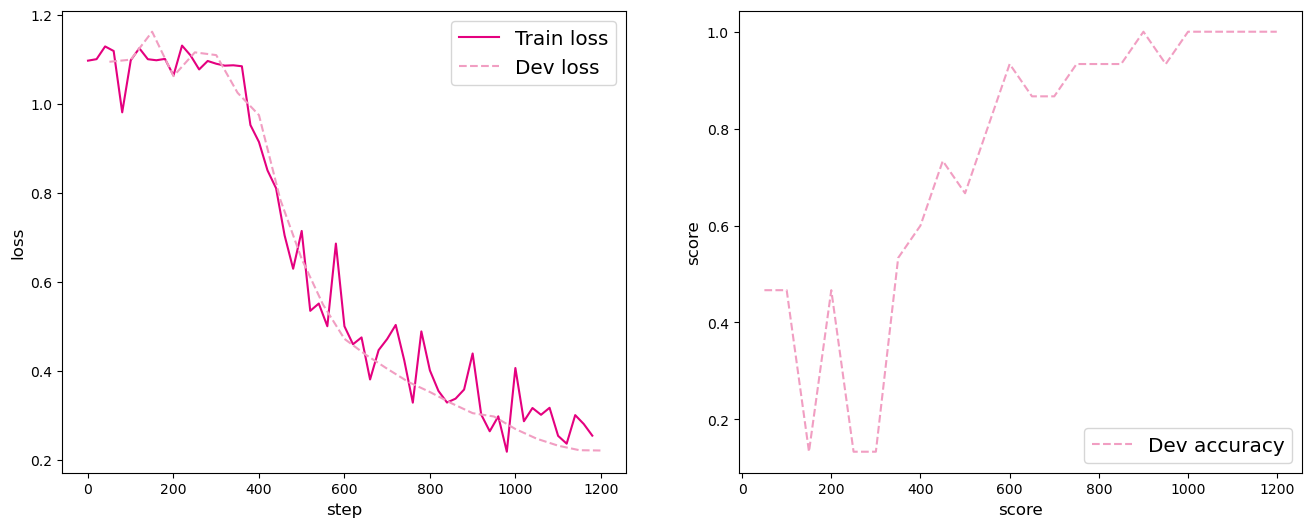

In [10]:
import matplotlib.pyplot as plt

# 绘制训练集和验证集的损失变化以及验证集上的准确率变化曲线
def plot_training_loss_acc(runner, fig_name,
                          fig_size=(16, 6),
                          sample_step=20,
                          loss_legend_loc="upper right",
                          acc_legend_loc="lower right",
                          train_color="#e4007f",
                          dev_color="#f19ec2",
                          fontsize="large",
                          train_linestyle="-",
                          dev_linestyle="--"):
    plt.figure(figsize=fig_size)

    plt.subplot(1, 2, 1)
    train_items = runner.train_step_losses[::sample_step]
    train_steps=[x[0] for x in train_items]
    train_losses = [x[1] for x in train_items]

    plt.plot(train_steps, train_losses, color=train_color,
            linestyle=train_linestyle, label="Train loss")
    if len(runner.dev_losses) > 0:
        dev_steps = [x[0] for x in runner.dev_losses]
        dev_losses = [x[1] for x in runner.dev_losses]
        plt.plot(dev_steps, dev_losses, color=dev_color, linestyle=dev_linestyle,
                label="Dev loss")
    # 绘制坐标轴和图例
    plt.ylabel("loss", fontsize=fontsize)
    plt.xlabel("step", fontsize=fontsize)
    plt.legend(loc=loss_legend_loc, fontsize="x-large")

    # 绘制评价准确率变化曲线
    if len(runner.dev_scores) > 0:
        plt.subplot(1, 2, 2)
        plt.plot(dev_steps, runner.dev_scores,
                color=dev_color, linestyle=dev_linestyle, label="Dev accuracy")

        # 绘制坐标轴和图例
        plt.ylabel("score", fontsize=fontsize)
        plt.xlabel("score", fontsize=fontsize)
        plt.legend(loc=acc_legend_loc, fontsize="x-large")

    plt.savefig(fig_name)
    plt.show()

plot_training_loss_acc(runner, "fw-loss.pdf")

### 4.5.6 模型评价

In [11]:
# 加载最优模型
runner.load_model("best_model.pdparams")
# 模型评价
score, loss = runner.evaluate(test_loader)
print("[Test] accuracy/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] accuracy/loss: 0.9333/0.3948


### 4.5.7 模型预测

In [12]:
# 获取测试集中第一条数据
X, label = next(test_loader())
logits = runner.predict(X)

# print(f"X is {X}")
# print(f"label is {label}")
# print(f"label[0] is {label[0]}")
# print(f"label[0][0] is {label[0][0]}")

pred_class = paddle.argmax(logits[0]).numpy()
label = label[0].numpy()  # 这里label[0][0]改为了label[0]

# 输出真实类别与预测类别
print("The true category is {} and the predicted category is {}".format(label, pred_class))

The true category is 2 and the predicted category is 2


## 4.7 实验拓展
基于MNIST手写数字识别数据集, 设计前馈神经网络，并取得95%以上的准确率

### 4.7.2 数据处理

In [2]:
import numpy as np
import paddle
import paddle.io as io
from nndl_study.dataset import load_data_mnist

class MNISTDataset(io.Dataset):
    def __init__(self, mode="train", num_train=1437, num_dev=179):
        super(MNISTDataset, self).__init__()
        X, y = load_data_mnist(shuffle=True)
        if mode == "train":
            self.X, self.y = X[:num_train], y[:num_train]
        elif mode == "dev":
            self.X, self.y = X[num_train: num_train + num_dev], y[num_train: num_train + num_dev]
        else:
            self.X, self.y = X[num_train + num_dev:], y[num_train + num_dev:]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.y)

In [3]:
paddle.seed(25)
train_dataset = MNISTDataset(mode="train")
dev_dataset = MNISTDataset(mode="dev")
test_dataset = MNISTDataset(mode="test")

In [4]:
# 打印训练集长度
print("length of train set: ", len(train_dataset))

length of train set:  1437


#### 4.7.2.2 用DataLoader进行封装

In [5]:
# 批量大小
batch_size = 16  # 批量大小一般在1~100之间，通常设置为2的n次幂

# 加载数据
train_loader = io.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = io.DataLoader(dev_dataset, batch_size=batch_size)
test_loader = io.DataLoader(test_dataset, batch_size=batch_size)

### 4.7.3 模型构建

In [6]:
from paddle import nn

# 定义前馈神经网络
class Model_MLP_L2_V3(nn.Layer):
    def __init__(self, input_size, output_size, hidden_size):
        super(Model_MLP_L2_V3, self).__init__()
        # 构建第一个全连接层
        self.fc1 = nn.Linear(
            input_size,
            hidden_size,
            weight_attr=paddle.ParamAttr(initializer=nn.initializer.Normal(mean=0.0,
                                                                          std=0.01)),
            bias_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0))
        )
        # 构建第二全连接层
        self.fc2 = nn.Linear(
            hidden_size,
            output_size,
            weight_attr=paddle.ParamAttr(initializer=nn.initializer.Normal(mean=0.0,
                                                                          std=0.01)),
            bias_attr=paddle.ParamAttr(initializer=nn.initializer.Constant(value=1.0))
        )
        # 定义网络使用的激活函数
        self.act = nn.Sigmoid()

    def forward(self, inputs):
        outputs = self.fc1(inputs)
        outputs = self.act(outputs)
        outputs = self.fc2(outputs)
        return outputs

fnn_model = Model_MLP_L2_V3(input_size=4, output_size=3, hidden_size=6)

### 4.7.4 完善Runner类

In [7]:
from paddle.metric import Metric

class Accuracy(Metric):
    def __init__(self, is_logist=True):
        """
        输入:
            - is_logist: outputs是logist还是激活后的值
        """

        # 用于统计正确的样本个数
        self.num_correct = 0
        # 用于统计样本的总数
        self.num_count = 0

        self.is_logist = is_logist

    def update(self, outputs, labels):
        """
        输入:
            - outputs: 预测值, shape=[N, class_num]
            - labels: 标签值, shape=[N, 1]
        """

        # 判断是二分类任务还是多分类任务, shape[1] = 1时为二分类任务, shape[1]>1时为多分类任务
        if outputs.shape[1] == 1:  # 二分类
            outputs = paddle.squeeze(outputs, axis=-1)
            if self.is_logist:
                # logist判断是否大于0
                preds = paddle.cast((outputs>=0), dtype="float32")
            else:
                # 如果不是logist, 判断每个概率值是否大于0.5, 当大于0.5时, 类别为1, 否则类别为0
                preds = paddle.cast((outputs>=0.5), dtype="float32")
        else:
            # 多分类时, 使用"paddle.argmax"计算最大元素索引作为类别
            preds = paddle.argmax(outputs, axis=1, dtype="int64")

        # 获取本批数据中预测正确的样本个数
        labels = paddle.squeeze(labels, axis=-1)
        batch_correct = paddle.sum(paddle.cast(preds==labels, dtype="float32")).numpy()[0]
        batch_count = len(labels)

        # 更新num_correct 和 num_count
        self.num_correct += batch_correct
        self.num_count += batch_count

    def accumulate(self):
        # 使用累计的数据, 计算总的指标
        if self.num_count == 0:
            return 0
        return self.num_correct / self.num_count

    def reset(self):
        # 重置正确的数目和总数
        self.num_correct = 0
        self.num_count = 0

    def name(self):
        return "Accuracy"

RunnerV3类的代码实现如下:

In [ ]:
import paddle.nn.functional as F

class RunnerV3(object):
    def __init__(self, model, optimizer, loss_fn, metric, **kwargs):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metric = metric  # 只用于计算评价指标

        # 记录训练过程中的评价指标变化情况
        self.dev_scores = []

        # 记录训练过程中的损失函数变化情况
        self.train_epoch_losses = []  # 一个epoch记录一次loss
        self.train_step_losses = []  # 一个step记录一次loss
        self.dev_losses = []

        # 记录全局最优指标
        self.best_score = 0

    def train(self, train_loader, dev_loader=None, **kwargs):
        # 将模型切换为训练模式
        self.model.train()

        # 传入训练轮数, 如果没有传入值则默认为0
        num_epochs = kwargs.get("num_epochs", 0)
        # 传入log打印频率, 如果没有传入值则默认为100
        log_steps = kwargs.get("log_steps", 100)
        # 评价频率
        eval_steps = kwargs.get("eval_steps", 0)

        # 传入模型保存路径, 如果没有传入值则默认为"best_model.pdparams"
        save_path = kwargs.get("save_path", "best_model.pdparams")

        custom_print_log = kwargs.get("custom_print_log", None)

        # 训练总的步数
        num_training_steps = num_epochs * len(train_loader)

        if eval_steps:
            if self.metric is None:
                raise RuntimeError("Error: Metric can not be None!")
            if dev_loader is None:
                raise RuntimeError("Error: dev_loader can not be None!")

        # 运行的step数目
        global_step = 0

        # 进行num_epochs轮训练
        for epoch in range(num_epochs):
            # 用于统计训练集的损失
            total_loss = 0
            for step, data in enumerate(train_loader):
                X, y = data
                # 获取模型预测
                logits = self.model(X)
                loss = self.loss_fn(logits, y)  # 默认求mean
                total_loss += loss

                # 训练过程中, 每个step的loss进行保存
                self.train_step_losses.append((global_step, loss.item()))

                if log_steps and global_step%log_steps == 0:
                    print(f"[Train] epoch: {epoch}/{num_epochs}, step: {
                    global_step}/{num_training_steps}, loss:{loss.item():.5f}")

                # 梯度反向传播, 计算每个参数的梯度值
                loss.backward()

                if custom_print_log:
                    custom_print_log(self)

                # 小批量梯度下降进行参数更新
                self.optimizer.step()
                # 梯度归零
                self.optimizer.clear_grad()

                # 判断是否需要评价
                if eval_steps > 0 and global_step > 0 and \
                (global_step % eval_steps == 0 or global_step == (num_training_steps-1)):
                    dev_score, dev_loss = self.evaluate(dev_loader, global_step=global_step)
                    print(f"[Evaluate] dev score: {dev_score:.5f}, dev loss: {dev_loss:.5f}")

                    # 将模型切换为训练模式
                    self.model.train()

                    # 如果当前指标为最优指标, 保存该模型
                    if dev_score > self.best_score:
                        self.save_model(save_path)
                        print(f"[Evaluate] best accuract performence has been updated: {
                        self.best_score:.5f} --> {dev_score:.5f}")
                        self.best_score = dev_score

                global_step += 1

            # 当前epoch训练loss累计值
            